# QuantCube GDP Nowcasting — Data Pipeline & Diagnostics


## 1. Environment setup

The notebook expects the project structure:

```text
QuantCubeProject/
├── data/
│   ├── raw/
│   └── processed/
├── notebooks/
└── src/
    ├── DataCollection.py
    ├── DataProcessing.py
    ├── DataAnalysis.py
    ├── DataSplitter.py
    ├── TrainingModels.py
    ├── AnalyseModels.py
    └── config.py
```

The code below automatically finds the project root whether the notebook is launched from the root or from `notebooks/`.


In [301]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)

#--- fetch paths ---

cwd = Path.cwd()

if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not find the project root. Expected a 'src/' directory "
        "in the current directory or its parent."
    )

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("Source dir   :", SRC_DIR)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/raphaelbreaud/Desktop/Project/QuantCubeProject
Source dir   : /Users/raphaelbreaud/Desktop/Project/QuantCubeProject/src


In [302]:
#--- class import ---

import config
import DataCollection
import DataProcessing
import DataAnalysis
import DataSplitter

## 2. Run configuration

In [303]:
OBSERVATION_START = "1990-01-01"
LOOKBACK_QUARTERS = 3
TEST_SIZE = 0.1

REFRESH_RAW_FEATURES = False

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

FRED_API_KEY = "2a022455c2b9c6a3008451167452c9b6"

if not FRED_API_KEY:
    raise ValueError(
        "FRED_API_KEY is not set. Set it in your environment before running this notebook."
    )

datacollect = DataCollection.DataCollection(
    api_key_fed=FRED_API_KEY
)

print("Observation start :", OBSERVATION_START)
print("Lookback quarters :", LOOKBACK_QUARTERS)
print("Test size         :", TEST_SIZE)
print("Refresh raw data  :", REFRESH_RAW_FEATURES)


Observation start : 1990-01-01
Lookback quarters : 3
Test size         : 0.1
Refresh raw data  : False


## 3. GDP release calendar and original label

Collect the **initial GDP release calendar**, and the **Labels**

GDP calendar saved to: /Users/raphaelbreaud/Desktop/Project/QuantCubeProject/data/raw/calendar_gdp.csv
get value for quarter_start : 1991-10-01 00:00:00
get value for quarter_start : 1992-01-01 00:00:00
get value for quarter_start : 1992-04-01 00:00:00
get value for quarter_start : 1992-07-01 00:00:00
get value for quarter_start : 1992-10-01 00:00:00
get value for quarter_start : 1993-01-01 00:00:00
get value for quarter_start : 1993-04-01 00:00:00
get value for quarter_start : 1993-07-01 00:00:00
get value for quarter_start : 1993-10-01 00:00:00
get value for quarter_start : 1994-01-01 00:00:00
get value for quarter_start : 1994-04-01 00:00:00
get value for quarter_start : 1994-07-01 00:00:00
get value for quarter_start : 1994-10-01 00:00:00
get value for quarter_start : 1995-01-01 00:00:00
get value for quarter_start : 1995-04-01 00:00:00
get value for quarter_start : 1995-07-01 00:00:00
get value for quarter_start : 1995-10-01 00:00:00
get value for quarter_start : 1996-01-01 00:00:

,quarter,quarter_start,quarter_end,release_date,release_lag_days,initial_value,initial_growth,quarterly_ratio,cutoff_date
0,1991Q4,1991-10-01,1991-12-31,1992-01-29,29,1.000000,0.296461,1.000740,1992-01-18
1,1992Q1,1992-01-01,1992-03-31,1992-04-28,28,1.004910,1.978356,1.004910,1992-04-18
2,1992Q2,1992-04-01,1992-06-30,1992-07-30,30,1.008374,1.385975,1.003447,1992-07-18
3,1992Q3,1992-07-01,1992-09-30,1992-10-27,27,1.014990,2.650422,1.006561,1992-10-18
4,1992Q4,1992-10-01,1992-12-31,1993-01-28,28,1.024474,3.790272,1.009344,1993-01-18


,quarter,quarter_start,quarter_end,release_date,release_lag_days,initial_value,initial_growth,quarterly_ratio,cutoff_date
134,2025Q2,2025-04-01,2025-06-30,2025-07-30,30,2.190862,2.968252,1.007339,2025-07-18
135,2025Q3,2025-07-01,2025-09-30,2025-12-23,84,2.214270,4.342784,1.010685,2025-10-18
136,2025Q4,2025-10-01,2025-12-31,2026-02-20,51,2.222103,1.422544,1.003538,2026-01-18
137,2026Q1,2026-01-01,2026-03-31,2026-04-30,30,2.233075,1.989722,1.004938,2026-04-18
138,2026Q2,2026-04-01,2026-06-30,2026-07-30,30,2.241403,1.500152,1.003729,2026-07-18



GDP release lag summary:


count    139.000000
mean      29.676259
std        6.268412
min       25.000000
1%        25.000000
5%        26.000000
10%       27.000000
25%       27.000000
50%       29.000000
75%       30.000000
90%       31.000000
95%       31.100000
99%       57.100000
max       84.000000
Name: release_lag_days, dtype: float64


Release lag quantiles:


,release_lag_days
1%,25.0
5%,26.0
10%,27.0
25%,27.0
50%,29.0
75%,30.0
90%,31.0
95%,31.1
99%,57.1


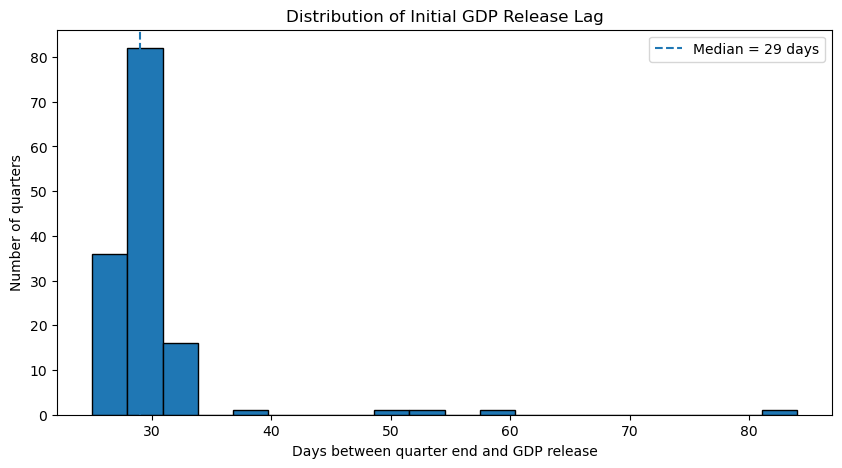

In [304]:
calendar = datacollect.get_release_dates(
    series_id="GDPC1",
    observation_start=OBSERVATION_START
)

calendar = datacollect.build_initial_gdp_growth()

print(
    "Calendar shape:",
    calendar.shape
)

print(
    "Quarter range:",
    calendar["quarter"].iloc[0],
    "->",
    calendar["quarter"].iloc[-1]
)

display(
    calendar.head()
)

display(
    calendar.tail()
)

release_lags = (
    calendar["release_lag_days"]
    .dropna()
)

print("\nGDP release lag summary:")

display(
    release_lags
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

quantiles = (
    release_lags
    .quantile(
        [
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .rename("release_lag_days")
    .to_frame()
)

quantiles.index = [
    "1%",
    "5%",
    "10%",
    "25%",
    "50%",
    "75%",
    "90%",
    "95%",
    "99%"
]

print("\nRelease lag quantiles:")

display(
    quantiles
)


# ==================================================
# Distribution
# ==================================================

plt.figure(
    figsize=(10, 5)
)

plt.hist(
    release_lags,
    bins=20,
    edgecolor="black"
)

plt.axvline(
    release_lags.median(),
    linestyle="--",
    label=(
        f"Median = "
        f"{release_lags.median():.0f} days"
    )
)

plt.xlabel(
    "Days between quarter end and GDP release"
)

plt.ylabel(
    "Number of quarters"
)

plt.title(
    "Distribution of Initial GDP Release Lag"
)

plt.legend()

plt.show()

In [305]:
print(calendar)

    quarter quarter_start quarter_end release_date  release_lag_days  initial_value  initial_growth  quarterly_ratio cutoff_date
0    1991Q4    1991-10-01  1991-12-31   1992-01-29                29       1.000000        0.296461         1.000740  1992-01-18
1    1992Q1    1992-01-01  1992-03-31   1992-04-28                28       1.004910        1.978356         1.004910  1992-04-18
2    1992Q2    1992-04-01  1992-06-30   1992-07-30                30       1.008374        1.385975         1.003447  1992-07-18
3    1992Q3    1992-07-01  1992-09-30   1992-10-27                27       1.014990        2.650422         1.006561  1992-10-18
4    1992Q4    1992-10-01  1992-12-31   1993-01-28                28       1.024474        3.790272         1.009344  1993-01-18
..      ...           ...         ...          ...               ...            ...             ...              ...         ...
134  2025Q2    2025-04-01  2025-06-30   2025-07-30                30       2.190862        2.9682

In [306]:
calendar_checks = pd.DataFrame({
    "metric": [
        "number_of_quarters",
        "missing_release_dates",
        "missing_initial_values",
        "duplicate_quarters",
        "missing_initial_growth",
        "min_release_lag_days",
        "median_release_lag_days",
        "max_release_lag_days",
    ],
    "value": [
        len(calendar),
        calendar["release_date"].isna().sum(),
        calendar["initial_value"].isna().sum(),
        calendar["quarter"].duplicated().sum(),
        calendar["initial_growth"].isna().sum(),
        calendar["release_lag_days"].min(),
        calendar["release_lag_days"].median(),
        calendar["release_lag_days"].max(),
    ]
})

display(calendar_checks)


,metric,value
0,number_of_quarters,139.0
1,missing_release_dates,0.0
2,missing_initial_values,0.0
3,duplicate_quarters,0.0
4,missing_initial_growth,0.0
5,min_release_lag_days,25.0
6,median_release_lag_days,29.0
7,max_release_lag_days,84.0


We observe no missing labels 

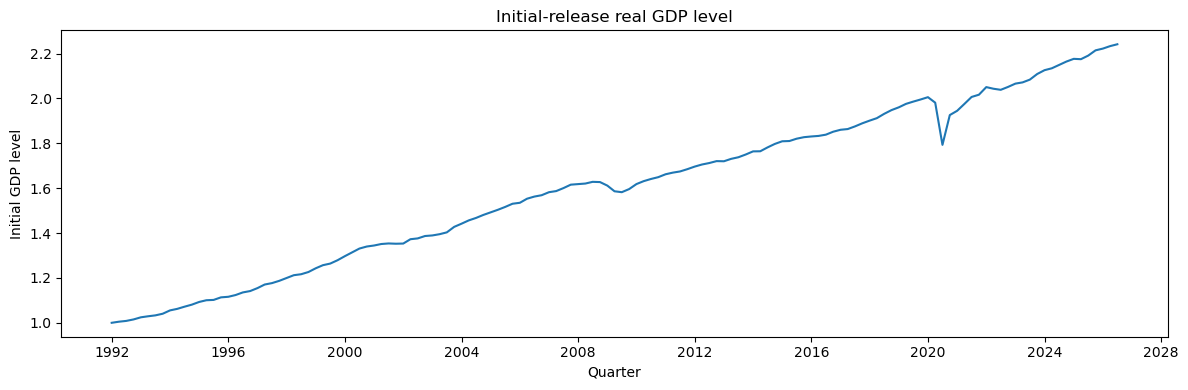

In [307]:
# Time-series view of the original initial GDP releases.

plt.figure(figsize=(12, 4))

plt.plot(
    pd.to_datetime(calendar["quarter_end"]),
    calendar["initial_value"]
)

plt.title("Initial-release real GDP level")
plt.xlabel("Quarter")
plt.ylabel("Initial GDP level")

plt.tight_layout()
plt.show()


## 5. Raw point-in-time feature snapshots

Each snapshot must represent **only information available at that cutoff_date**.

For every cutoff date, the raw file contains the historical observations of every FRED feature as known on that date.


In [ ]:
RAW_FEATURES_PATH = RAW_DIR / "raw_features.pkl"
FORCE_RECOLT = True

if FORCE_RECOLT:
    snapshots = datacollect.get_features_by_cutoff(
            calendar=calendar,
            fred_features=config.FRED_FEATURES,
            lookback_quarters=LOOKBACK_QUARTERS
        )
else:

    if REFRESH_RAW_FEATURES or not RAW_FEATURES_PATH.exists():

        snapshots = datacollect.get_features_by_cutoff(
            calendar=calendar,
            fred_features=config.FRED_FEATURES,
            lookback_quarters=LOOKBACK_QUARTERS
        )

    else:

        snapshots = pd.read_pickle(
            RAW_FEATURES_PATH
        )

        print(
            "Loaded existing raw snapshots from:",
            RAW_FEATURES_PATH
        )

    print("Number of cutoff snapshots:", len(snapshots))

if snapshots:
    snapshot_dates = sorted(pd.to_datetime(list(snapshots.keys())))
    print("First cutoff:", snapshot_dates[0].date())
    print("Last cutoff :", snapshot_dates[-1].date())


Loaded existing raw snapshots from: /Users/raphaelbreaud/Desktop/Project/QuantCubeProject/data/raw/raw_features.pkl
Number of cutoff snapshots: 139
First cutoff: 1992-01-18
Last cutoff : 2026-07-18


In [309]:
latest_cutoff = max(snapshots.keys())
latest_snapshot = snapshots[latest_cutoff].copy()

print("Latest cutoff       :", pd.Timestamp(latest_cutoff).date())
print("Raw rows            :", len(latest_snapshot))
print("Number of series    :", latest_snapshot["series_id"].nunique())
print("Missing raw values  :", latest_snapshot["value"].isna().sum())

display(latest_snapshot.head(20))


Latest cutoff       : 2026-07-18
Raw rows            : 237
Number of series    : 21
Missing raw values  : 1


,observation_date,realtime_start,realtime_end,value,cutoff_date,quarter_end,series_id,feature_name
0,2025-10-01,2026-07-18,2026-07-18,605401.0,2026-07-18,2026-06-30,AMTMNO,manufacturing_new_orders
1,2025-11-01,2026-07-18,2026-07-18,621859.0,2026-07-18,2026-06-30,AMTMNO,manufacturing_new_orders
2,2025-12-01,2026-07-18,2026-07-18,619137.0,2026-07-18,2026-06-30,AMTMNO,manufacturing_new_orders
3,2026-01-01,2026-07-18,2026-07-18,619352.0,2026-07-18,2026-06-30,AMTMNO,manufacturing_new_orders
4,2026-02-01,2026-07-18,2026-07-18,621304.0,2026-07-18,2026-06-30,AMTMNO,manufacturing_new_orders
5,2026-03-01,2026-07-18,2026-07-18,632650.0,2026-07-18,2026-06-30,AMTMNO,manufacturing_new_orders
6,2026-04-01,2026-07-18,2026-07-18,665895.0,2026-07-18,2026-06-30,AMTMNO,manufacturing_new_orders
7,2026-05-01,2026-07-18,2026-07-18,657373.0,2026-07-18,2026-06-30,AMTMNO,manufacturing_new_orders
8,2025-10-01,2026-07-18,2026-07-18,77817.0,2026-07-18,2026-06-30,ANXAVS,capital_goods_shipments
9,2025-11-01,2026-07-18,2026-07-18,78015.0,2026-07-18,2026-06-30,ANXAVS,capital_goods_shipments


## 6. Inspect the preprocessing assumptions

Before transforming the data, inspect both:

1. the FRED metadata for every feature, and  
2. the transformation rules used by `PREPROCESSING_CONFIG`.

This makes it easier to catch an inappropriate log transformation, frequency mismatch, or unexpected unit.


In [310]:
fred_metadata = datacollect.build_preprocessing_config(
    config.FRED_FEATURES
)

fred_metadata_df = (
    pd.DataFrame
    .from_dict(
        fred_metadata,
        orient="index"
    )
    .rename_axis("series_id")
    .reset_index()
)

display(fred_metadata_df)


,series_id,feature_name,frequency,units,seasonal_adjustment
0,PCEC96,real_pce,M,Billions of Chained 2017 Dollars,SAAR
1,RSAFS,retail_sales,M,Millions of Dollars,SA
2,TOTALSA,vehicle_sales,M,Millions of Units,SAAR
3,DSPIC96,real_disposable_income,M,Billions of Chained 2017 Dollars,SAAR
4,HOUST,housing_starts,M,Thousands of Units,SAAR
5,PERMIT,building_permits,M,Thousands of Units,SAAR
6,TLRESCONS,residential_construction,M,Millions of Dollars,SAAR
7,ANXAVS,capital_goods_shipments,M,Millions of Dollars,SA
8,TLNRESCONS,nonresidential_construction,M,Millions of Dollars,SAAR
9,AMTMNO,manufacturing_new_orders,M,Millions of Dollars,SA


In [311]:
preprocessing_rules_df = (
    pd.DataFrame
    .from_dict(
        config.PREPROCESSING_CONFIG,
        orient="index"
    )
    .rename_axis("series_id")
    .reset_index()
)

display(preprocessing_rules_df)


,series_id,feature_name,frequency,units,seasonal_adjustment,transform,windows
0,PCEC96,real_pce,M,Billions of Chained 2017 Dollars,SAAR,log_growth,"[1, 3]"
1,RSAFS,retail_sales,M,Millions of Dollars,SA,log_growth,"[1, 3]"
2,TOTALSA,vehicle_sales,M,Millions of Units,SAAR,log_growth,"[1, 3]"
3,DSPIC96,real_disposable_income,M,Billions of Chained 2017 Dollars,SAAR,log_growth,"[1, 3]"
4,HOUST,housing_starts,M,Thousands of Units,SAAR,log_growth,"[1, 3]"
5,PERMIT,building_permits,M,Thousands of Units,SAAR,log_growth,"[1, 3]"
6,TLRESCONS,residential_construction,M,Millions of Dollars,SAAR,log_growth,"[1, 3]"
7,ANXAVS,capital_goods_shipments,M,Millions of Dollars,SA,log_growth,"[1, 3]"
8,TLNRESCONS,nonresidential_construction,M,Millions of Dollars,SAAR,log_growth,"[1, 3]"
9,AMTMNO,manufacturing_new_orders,M,Millions of Dollars,SA,log_growth,"[1, 3]"


## 7. Raw-data diagnostics

This stage answers:

- Which series are historically available?
- Which series have missing raw observations?
- When does coverage begin?
- Does the latest cutoff look sensible?

These checks happen **before feature engineering**.


## 8. Build processed features

Now transform the raw snapshots into one feature row per quarter-end cutoff.

In [312]:
dataprocess = DataProcessing.DataProcessing()

features = dataprocess.build_features()
features = dataprocess.features_cleaning()

if features is None:
    features = pd.read_csv(
        dataprocess.processed_features_path,
        parse_dates=["cutoff_date"]
    )

if features.index.name == "cutoff_date":
    features_for_merge = features.reset_index()
else:
    features_for_merge = features.copy()
    features_for_merge["cutoff_date"] = pd.to_datetime(
        features_for_merge["cutoff_date"]
    )

features_for_merge = (
    features_for_merge
    .sort_values("cutoff_date")
    .reset_index(drop=True)
)

print("Processed feature matrix shape:", features_for_merge.shape)
print(
    "Feature date range:",
    features_for_merge["cutoff_date"].min(),
    "->",
    features_for_merge["cutoff_date"].max()
)

display(features_for_merge.head())
display(features_for_merge.tail())


features to dropp ; ['business_inventories_diff_1', 'business_inventories_diff_3', 'building_permits_growth_1', 'building_permits_growth_3', 'pce_price_index_growth_1', 'pce_price_index_growth_3', 'retail_sales_growth_1', 'retail_sales_growth_3', 'initial_claims_mean_1', 'initial_claims_mean_4', 'initial_claims_mean_13', 'exports_growth_1', 'exports_growth_3', 'imports_growth_1', 'imports_growth_3', 'residential_construction_growth_1', 'residential_construction_growth_3', 'capital_goods_shipments_growth_1', 'capital_goods_shipments_growth_3', 'nonresidential_construction_growth_1', 'nonresidential_construction_growth_3', 'manufacturing_new_orders_growth_1', 'manufacturing_new_orders_growth_3', 'public_construction_growth_1', 'public_construction_growth_3', 'national_activity_index_mean_1', 'national_activity_index_mean_3', 'financial_conditions_mean_1', 'financial_conditions_mean_4', 'financial_conditions_mean_13', 'vehicle_sales_growth_1', 'vehicle_sales_growth_3']
Original features: 

,cutoff_date,real_pce_growth_1,real_pce_growth_3,real_disposable_income_growth_1,real_disposable_income_growth_3,housing_starts_growth_1,housing_starts_growth_3,industrial_production_growth_1,industrial_production_growth_3,nonfarm_payrolls_diff_1,nonfarm_payrolls_diff_3,cpi_growth_1,cpi_growth_3,news_sentiment_latest,news_sentiment_mean_30d,news_sentiment_mean_90d,news_sentiment_momentum
0,1992-01-18,0.360790,0.287304,-0.451991,-0.268616,-2.134652,0.942514,-0.185357,-0.555043,31.0,-227.0,0.289855,0.799132,-0.008506,-0.066636,-0.091208,0.024572
1,1992-04-18,0.564487,1.345516,0.683763,1.346755,6.195334,19.961305,0.280243,-0.186393,19.0,4.0,0.503417,0.864559,0.053806,0.081756,0.061239,0.020517
2,1992-07-18,0.253562,-0.093414,0.091788,0.437442,-3.204321,-13.823326,-0.369004,0.556072,-117.0,153.0,0.285511,0.643549,-0.024632,0.009692,0.014894,-0.005202
3,1992-10-18,0.057301,0.969470,-0.560571,-0.582929,9.936041,3.370644,-0.275862,0.092123,-57.0,-14.0,0.212691,0.639434,-0.062933,-0.059355,-0.012744,-0.046610
4,1993-01-18,0.301254,1.270810,-0.119211,0.539610,1.459880,0.727276,0.362648,1.458549,64.0,214.0,0.070348,0.705719,0.186400,0.231914,0.104920,0.126994


,cutoff_date,real_pce_growth_1,real_pce_growth_3,real_disposable_income_growth_1,real_disposable_income_growth_3,housing_starts_growth_1,housing_starts_growth_3,industrial_production_growth_1,industrial_production_growth_3,nonfarm_payrolls_diff_1,nonfarm_payrolls_diff_3,cpi_growth_1,cpi_growth_3,news_sentiment_latest,news_sentiment_mean_30d,news_sentiment_mean_90d,news_sentiment_momentum
134,2025-07-18,-0.277630,0.493561,-0.690615,0.583509,4.489918,-2.541243,0.334092,0.326375,147.0,449.0,0.286569,0.588040,-0.024331,-0.064511,-0.078981,0.014471
135,2025-10-18,0.349066,0.990578,0.110022,0.307148,-8.924046,1.931308,0.097141,0.253689,22.0,88.0,0.381722,0.864677,-0.154798,-0.066098,-0.012536,-0.053562
136,2026-01-18,0.108379,0.913447,0.053783,0.433862,-4.703061,-13.071845,0.364406,0.536103,50.0,-67.0,0.306884,0.821078,0.025465,0.023208,-0.043676,0.066884
137,2026-04-18,0.103653,0.199013,-0.453646,0.122722,6.961753,15.617020,-0.542979,0.175515,178.0,205.0,0.861423,1.298767,-0.201432,-0.197266,-0.061228,-0.136038
138,2026-07-18,0.261469,0.530816,0.250539,-0.377959,17.408646,-6.445092,0.076901,1.001004,57.0,334.0,-0.423377,0.686421,0.109474,0.031715,-0.049440,0.081155


## 9. Processed-feature diagnostics

These diagnostics matter more for modeling than the raw snapshot alone.

We inspect:

- number of quarters vs number of features,
- missingness after transformation,
- distributions,
- zero/low-variance features,
- high pairwise correlations.

This is the stage that tells us whether manual reduction, Ridge, PCA, or PLS is likely to be useful.


In [313]:
# Reload analysis after processed_features.csv has been created/updated.
processed_analysis = DataAnalysis.DataAnalysis()

display(processed_analysis.dimensionality_summary())


,n_observations,n_features,observations_per_feature
0,139,17,8.176471


In [314]:
missing_summary = processed_analysis.processed_missing_summary()

display(missing_summary)

print("\nFeatures with > 20% missing values:")
display(
    missing_summary[
        missing_summary["missing_pct"] > 20
    ]
)


,feature,n_missing,missing_pct
0,Unnamed: 0,0,0.0
1,nonfarm_payrolls_diff_1,0,0.0
2,news_sentiment_mean_90d,0,0.0
3,news_sentiment_mean_30d,0,0.0
4,news_sentiment_latest,0,0.0
5,cpi_growth_3,0,0.0
6,cpi_growth_1,0,0.0
7,nonfarm_payrolls_diff_3,0,0.0
8,industrial_production_growth_3,0,0.0
9,real_pce_growth_1,0,0.0



Features with > 20% missing values:


,feature,n_missing,missing_pct


In [315]:
distribution_summary = processed_analysis.processed_distribution_summary()

display(distribution_summary)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_pct,skewness,kurtosis
Unnamed: 0,139.0,69.000000,40.269923,0.000000,1.380000,6.900000,34.500000,69.000000,103.500000,131.100000,136.620000,138.000000,0.0,0.000000,-1.200000
real_pce_growth_1,139.0,0.270041,0.717360,-1.232540,-0.856610,-0.370980,0.059015,0.219799,0.435132,0.704309,0.925630,7.759898,0.0,8.228456,87.177280
real_pce_growth_3,139.0,0.666843,1.328787,-11.882717,-0.604405,-0.071007,0.358036,0.753604,1.016123,1.351357,3.241522,7.562316,0.0,-5.036964,63.039311
real_disposable_income_growth_1,139.0,0.105556,1.119554,-8.542327,-4.509988,-0.573575,-0.018176,0.223560,0.410051,1.006441,1.745810,5.117861,0.0,-3.794456,31.767187
real_disposable_income_growth_3,139.0,0.595290,1.250774,-5.614553,-4.233408,-0.772900,0.243535,0.624289,0.964035,2.129704,4.706465,5.825244,0.0,-0.684829,9.913050
housing_starts_growth_1,139.0,-0.026237,8.364912,-25.478786,-23.581747,-14.218187,-5.174362,0.793655,5.085416,12.620177,17.584989,19.652371,0.0,-0.447326,0.588191
housing_starts_growth_3,139.0,-0.133210,9.997177,-31.217954,-28.269656,-16.558533,-5.159417,0.942514,5.194116,14.647437,22.711305,31.054021,0.0,-0.300515,1.199646
industrial_production_growth_1,139.0,0.116082,0.883512,-5.552214,-2.538374,-0.756020,-0.192331,0.228468,0.460263,0.891614,1.510459,5.272396,0.0,-0.902100,20.183194
industrial_production_growth_3,139.0,0.435349,1.440292,-6.941382,-5.417963,-1.576285,-0.115912,0.624974,1.283083,2.076168,2.947223,3.916275,0.0,-1.977313,7.707593
nonfarm_payrolls_diff_1,139.0,156.532374,448.554010,-701.000000,-610.180000,-141.900000,26.500000,146.000000,222.500000,382.700000,890.920000,4800.000000,0.0,8.062501,84.254506


In [316]:
#maye here plot a correlation matrices 

high_corr = processed_analysis.high_correlations(
    threshold=0.85
)

print(
    "Number of feature pairs with |correlation| >= 0.85:",
    len(high_corr)
)

display(high_corr.head(50))


Number of feature pairs with |correlation| >= 0.85: 4


,feature_1,feature_2,correlation,abs_correlation
0,news_sentiment_latest,news_sentiment_mean_30d,0.975792,0.975792
1,news_sentiment_mean_30d,news_sentiment_mean_90d,0.928315,0.928315
2,news_sentiment_latest,news_sentiment_mean_90d,0.877143,0.877143
3,real_pce_growth_3,nonfarm_payrolls_diff_3,0.870357,0.870357


### Visualize a manageable subset of feature distributions

Instead of drawing every feature immediately, plot the six features with the largest absolute skewness. These are often the most useful distributions to inspect first for extreme values or transformation issues.


Features selected for distribution plots:
['nonfarm_payrolls_diff_3', 'real_pce_growth_1', 'nonfarm_payrolls_diff_1', 'real_pce_growth_3', 'real_disposable_income_growth_1', 'industrial_production_growth_3']


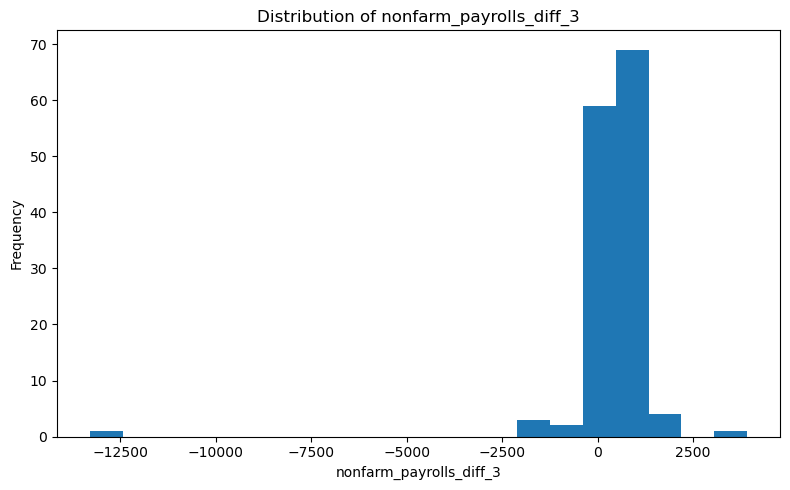

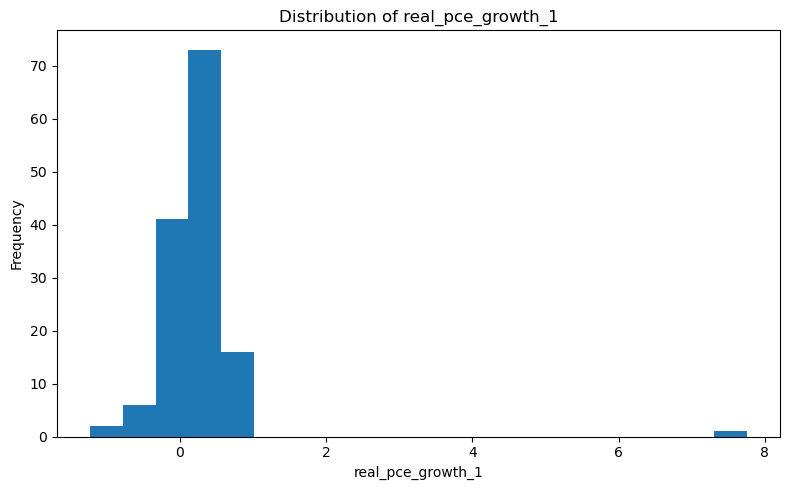

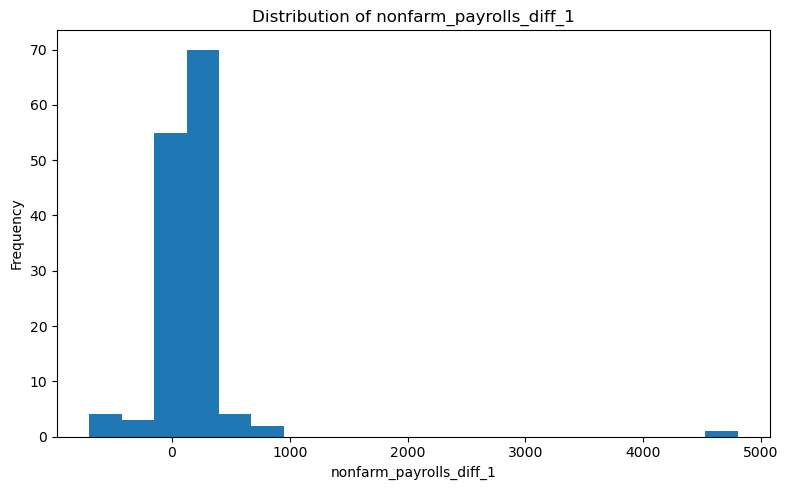

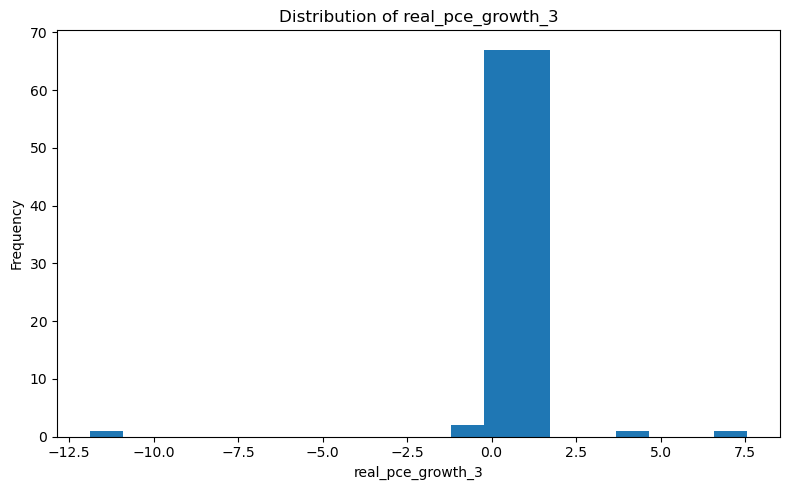

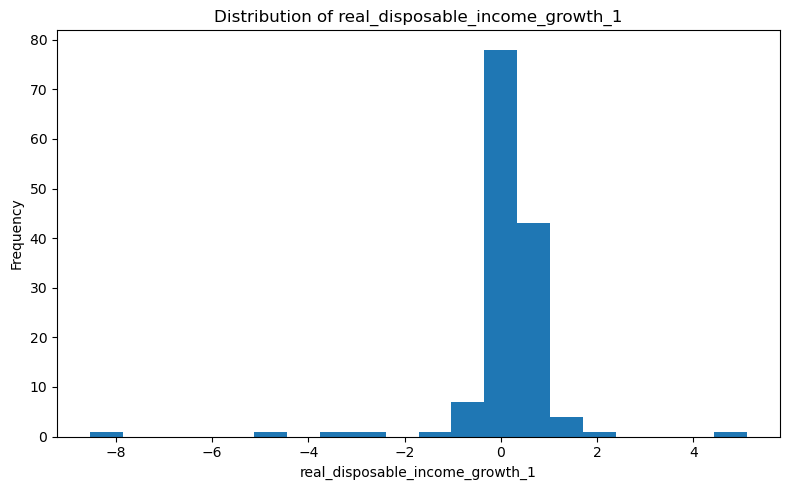

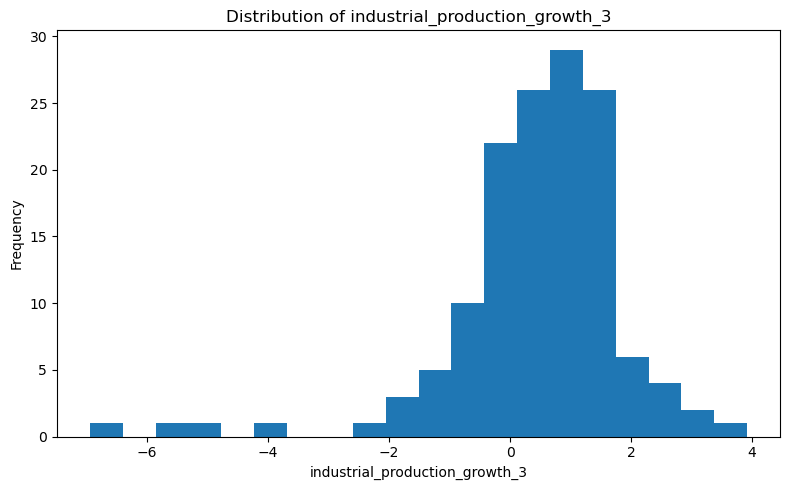

In [317]:
#maybe plot here features distributions 

if not distribution_summary.empty:

    skew_table = distribution_summary.copy()

    skew_table["abs_skewness"] = (
        skew_table["skewness"].abs()
    )

    features_to_plot = (
        skew_table
        .sort_values(
            "abs_skewness",
            ascending=False
        )
        .head(6)
        .index
        .tolist()
    )

    print("Features selected for distribution plots:")
    print(features_to_plot)

    for feature in features_to_plot:
        processed_analysis.plot_feature_distribution(
            feature
        )


## 10. Create the final modeling dataset

In [318]:
# ==================================================
# Choose target
# ==================================================

TARGET_TYPE = "annualized_growth"

# Possible values:
# "level"
# "difference"
# "pct_change"
# "log_growth"
# "annualized_log_growth"
# "annualized_growth"


labels_df = dataprocess.build_labels(
    label_type=TARGET_TYPE
)

print(
    f"Target type: {TARGET_TYPE}"
)

display(
    labels_df.head()
)

final_df = dataprocess.create_final_df()

print(
    "Final dataset shape:",
    final_df.shape
)

display(
    final_df.head()
)

display(
    final_df.tail()
)


Target type: annualized_growth


,quarter_end,gdp_initial,initial_growth,cutoff_date,last_quarter_gdp,target
0,1991-12-31,1.000000,0.296461,1992-01-18,NaN,0.296461
1,1992-03-31,1.004910,1.978356,1992-04-18,1.000000,1.978356
2,1992-06-30,1.008374,1.385975,1992-07-18,1.004910,1.385975
3,1992-09-30,1.014990,2.650422,1992-10-18,1.008374,2.650422
4,1992-12-31,1.024474,3.790272,1993-01-18,1.014990,3.790272


Final dataset shape: (139, 22)


,cutoff_date,real_pce_growth_1,real_pce_growth_3,real_disposable_income_growth_1,real_disposable_income_growth_3,housing_starts_growth_1,housing_starts_growth_3,industrial_production_growth_1,industrial_production_growth_3,nonfarm_payrolls_diff_1,nonfarm_payrolls_diff_3,cpi_growth_1,cpi_growth_3,news_sentiment_latest,news_sentiment_mean_30d,news_sentiment_mean_90d,news_sentiment_momentum,quarter_end,gdp_initial,initial_growth,last_quarter_gdp,target
0,1992-01-18,0.360790,0.287304,-0.451991,-0.268616,-2.134652,0.942514,-0.185357,-0.555043,31.0,-227.0,0.289855,0.799132,-0.008506,-0.066636,-0.091208,0.024572,1991-12-31,1.000000,0.296461,NaN,0.296461
1,1992-04-18,0.564487,1.345516,0.683763,1.346755,6.195334,19.961305,0.280243,-0.186393,19.0,4.0,0.503417,0.864559,0.053806,0.081756,0.061239,0.020517,1992-03-31,1.004910,1.978356,1.000000,1.978356
2,1992-07-18,0.253562,-0.093414,0.091788,0.437442,-3.204321,-13.823326,-0.369004,0.556072,-117.0,153.0,0.285511,0.643549,-0.024632,0.009692,0.014894,-0.005202,1992-06-30,1.008374,1.385975,1.004910,1.385975
3,1992-10-18,0.057301,0.969470,-0.560571,-0.582929,9.936041,3.370644,-0.275862,0.092123,-57.0,-14.0,0.212691,0.639434,-0.062933,-0.059355,-0.012744,-0.046610,1992-09-30,1.014990,2.650422,1.008374,2.650422
4,1993-01-18,0.301254,1.270810,-0.119211,0.539610,1.459880,0.727276,0.362648,1.458549,64.0,214.0,0.070348,0.705719,0.186400,0.231914,0.104920,0.126994,1992-12-31,1.024474,3.790272,1.014990,3.790272


,cutoff_date,real_pce_growth_1,real_pce_growth_3,real_disposable_income_growth_1,real_disposable_income_growth_3,housing_starts_growth_1,housing_starts_growth_3,industrial_production_growth_1,industrial_production_growth_3,nonfarm_payrolls_diff_1,nonfarm_payrolls_diff_3,cpi_growth_1,cpi_growth_3,news_sentiment_latest,news_sentiment_mean_30d,news_sentiment_mean_90d,news_sentiment_momentum,quarter_end,gdp_initial,initial_growth,last_quarter_gdp,target
134,2025-07-18,-0.277630,0.493561,-0.690615,0.583509,4.489918,-2.541243,0.334092,0.326375,147.0,449.0,0.286569,0.588040,-0.024331,-0.064511,-0.078981,0.014471,2025-06-30,2.190862,2.968252,2.174899,2.968252
135,2025-10-18,0.349066,0.990578,0.110022,0.307148,-8.924046,1.931308,0.097141,0.253689,22.0,88.0,0.381722,0.864677,-0.154798,-0.066098,-0.012536,-0.053562,2025-09-30,2.214270,4.342784,2.190862,4.342784
136,2026-01-18,0.108379,0.913447,0.053783,0.433862,-4.703061,-13.071845,0.364406,0.536103,50.0,-67.0,0.306884,0.821078,0.025465,0.023208,-0.043676,0.066884,2025-12-31,2.222103,1.422544,2.214270,1.422544
137,2026-04-18,0.103653,0.199013,-0.453646,0.122722,6.961753,15.617020,-0.542979,0.175515,178.0,205.0,0.861423,1.298767,-0.201432,-0.197266,-0.061228,-0.136038,2026-03-31,2.233075,1.989722,2.222103,1.989722
138,2026-07-18,0.261469,0.530816,0.250539,-0.377959,17.408646,-6.445092,0.076901,1.001004,57.0,334.0,-0.423377,0.686421,0.109474,0.031715,-0.049440,0.081155,2026-06-30,2.241403,1.500152,2.233075,1.500152


## 11. Final target and alignment checks

Before splitting, verify:

- one row per cutoff,
- chronological ordering,
- no missing target values,
- target distribution,
- correct quarter alignment,
- feature missingness is still allowed because the model pipeline will impute it later.


In [319]:
final_checks = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "duplicate_cutoff_dates",
        "missing_target",
        "feature_nan_cells",
        "first_cutoff",
        "last_cutoff",
    ],
    "value": [
        final_df.shape[0],
        final_df.shape[1],
        final_df["cutoff_date"].duplicated().sum(),
        final_df["target"].isna().sum(),
        final_df.drop(columns=["cutoff_date", "target"]).isna().sum().sum(),
        final_df["cutoff_date"].min(),
        final_df["cutoff_date"].max(),
    ]
})

display(final_checks)

assert final_df["cutoff_date"].is_monotonic_increasing
assert final_df["cutoff_date"].duplicated().sum() == 0

# Manually inspect target alignment for a few rows.

display(
    final_df[
        [
            "cutoff_date",
            "target"
        ]
    ].head(10)
)


,metric,value
0,rows,139
1,columns,22
2,duplicate_cutoff_dates,0
3,missing_target,0
4,feature_nan_cells,1
5,first_cutoff,1992-01-18 00:00:00
6,last_cutoff,2026-07-18 00:00:00


,cutoff_date,target
0,1992-01-18,0.296461
1,1992-04-18,1.978356
2,1992-07-18,1.385975
3,1992-10-18,2.650422
4,1993-01-18,3.790272
5,1993-04-18,1.799303
6,1993-07-18,1.577276
7,1993-10-18,2.844373
8,1994-01-18,5.870053
9,1994-04-18,2.581260


In [320]:
final_analysis = DataAnalysis.DataAnalysis()

display(final_analysis.target_summary(
    target_col="target"
))

display(final_analysis.target_extremes(
    target_col="target",
    n=8
))


,n_observations,n_missing,missing_pct,mean,std,min,median,max,skewness,kurtosis
0,139,0,0.0,2.456459,4.450608,-32.904137,2.566653,33.081827,-1.365339,44.31485


,cutoff_date,target
114,2020-07-18,-32.904137
69,2009-04-18,-6.143680
113,2020-04-18,-4.783095
68,2009-01-18,-3.803667
121,2022-04-18,-1.414108
70,2009-07-18,-1.017341
122,2022-07-18,-0.934183
39,2001-10-18,-0.354922
115,2020-10-18,33.081827
47,2003-10-18,7.154641


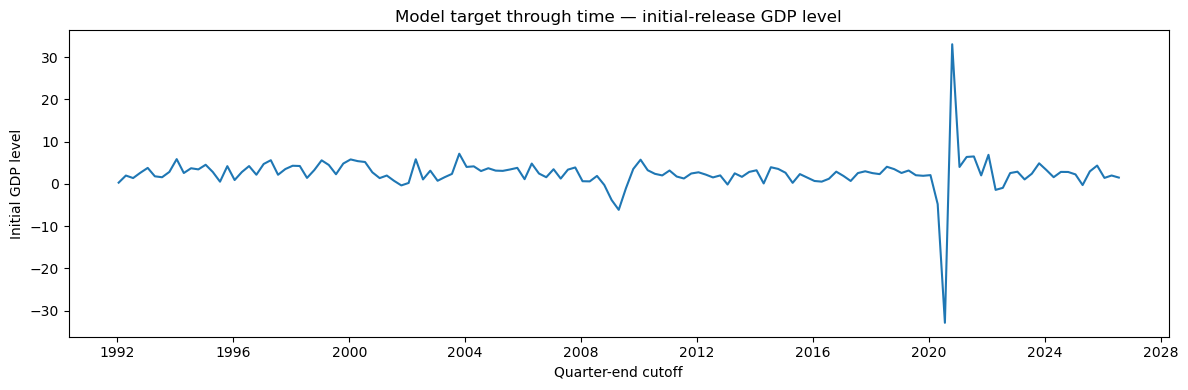

In [321]:
plt.figure(figsize=(12, 4))

plt.plot(
    pd.to_datetime(final_df["cutoff_date"]),
    final_df["target"]
)

plt.title("Model target through time — initial-release GDP level")
plt.xlabel("Quarter-end cutoff")
plt.ylabel("Initial GDP level")

plt.tight_layout()
plt.show()


## 12. Chronological train/test split


In [322]:
datasplitter = DataSplitter.DataSplitter(
    final_df,
    target_col="target",
    date_col="cutoff_date",
    test_size=TEST_SIZE
)

(
    X_train,
    X_test,
    y_train,
    y_test,
    dates_train,
    dates_test
) = datasplitter.train_test_split()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print(
    "\nTrain period:",
    pd.to_datetime(dates_train).min(),
    "->",
    pd.to_datetime(dates_train).max()
)

print(
    "Test period :",
    pd.to_datetime(dates_test).min(),
    "->",
    pd.to_datetime(dates_test).max()
)

print("\nMissing y_train:", y_train.isna().sum())
print("Missing y_test :", y_test.isna().sum())
print("Missing X_train cells:", X_train.isna().sum().sum())
print("Missing X_test cells :", X_test.isna().sum().sum())


X_train: (125, 16)
X_test : (14, 16)
y_train: (125,)
y_test : (14,)

Train period: 1992-01-18 00:00:00 -> 2023-01-18 00:00:00
Test period : 2023-04-18 00:00:00 -> 2026-07-18 00:00:00

Missing y_train: 0
Missing y_test : 0
Missing X_train cells: 0
Missing X_test cells : 0


In [323]:
train_missing = pd.DataFrame({
    "n_missing": X_train.isna().sum(),
    "missing_pct": 100 * X_train.isna().mean()
}).sort_values(
    "missing_pct",
    ascending=False
)

display(train_missing)


,n_missing,missing_pct
real_pce_growth_1,0,0.0
real_pce_growth_3,0,0.0
real_disposable_income_growth_1,0,0.0
real_disposable_income_growth_3,0,0.0
housing_starts_growth_1,0,0.0
housing_starts_growth_3,0,0.0
industrial_production_growth_1,0,0.0
industrial_production_growth_3,0,0.0
nonfarm_payrolls_diff_1,0,0.0
nonfarm_payrolls_diff_3,0,0.0


In [324]:
print(X_train.columns)

Index(['real_pce_growth_1', 'real_pce_growth_3', 'real_disposable_income_growth_1', 'real_disposable_income_growth_3', 'housing_starts_growth_1',
       'housing_starts_growth_3', 'industrial_production_growth_1', 'industrial_production_growth_3', 'nonfarm_payrolls_diff_1', 'nonfarm_payrolls_diff_3',
       'cpi_growth_1', 'cpi_growth_3', 'news_sentiment_latest', 'news_sentiment_mean_30d', 'news_sentiment_mean_90d', 'news_sentiment_momentum'],
      dtype='object')


## 13. Stop and review before dimensionality reduction

At this point, inspect these outputs before deciding on PCA:

1. `dimensionality_summary()`
2. `processed_missing_summary()`
3. `high_correlations()`
4. train-only missingness
5. target distribution
6. raw feature coverage

A sensible sequence for the **level target** is:

```text
Persistence benchmark: GDP_t ≈ GDP_(t-1)
    ↓
Ridge with previous-quarter GDP anchor
    ↓
manual redundancy reduction
    ↓
PCA + Ridge
    ↓
possibly PLS
    ↓
tree models as comparison
```

Do **not** fit PCA on `final_df` here. PCA belongs inside the cross-validation pipeline.


## 14. Optional model training

Keep this disabled while you are still diagnosing the data. When ready, switch `RUN_MODEL = True`.

Start with Ridge because it is well suited to a small quarterly sample with correlated macroeconomic predictors.


  0%|          | 0/50 [00:00<?, ?it/s]

Best model saved to: /Users/raphaelbreaud/Desktop/Project/QuantCubeProject/data/models/lasso/best_model.pkl

Model: lasso
CV RMSE: 2.0746 +/- 1.2482
Best parameters: {'alpha': 0.02996876792465927}
CV score: {'rmse_mean': 2.074579471980395, 'rmse_std': 1.2481795065280483}
OOF predictions saved to: /Users/raphaelbreaud/Desktop/Project/QuantCubeProject/data/models/lasso/oof_predictions.csv


,row_index,y_true,y_pred,fold,cutoff_date,error,absolute_error,squared_error
0,25,4.241671,2.147803,1,1998-04-18,2.093868,2.093868,4.384283
1,26,1.416765,1.822334,1,1998-07-18,-0.405569,0.405569,0.164486
2,27,3.288397,2.734635,1,1998-10-18,0.553762,0.553762,0.306652
3,28,5.584778,3.894603,1,1999-01-18,1.690175,1.690175,2.856691
4,29,4.491725,2.536756,1,1999-04-18,1.954969,1.954969,3.821903


,model,sample,MAE,RMSE,R2,MAPE_pct
0,lasso,train,1.189121,1.630075,0.877457,93.513573
1,lasso,OOF_train,1.406255,2.421122,0.778722,131.394201
2,lasso,test,1.044054,1.198618,0.122887,72.292619


,rank,feature,coefficient,abs_coefficient,selected
0,1,real_pce_growth_3,3.221456,3.221456,True
1,2,industrial_production_growth_3,0.791422,0.791422,True
2,3,nonfarm_payrolls_diff_3,0.699079,0.699079,True
3,4,real_disposable_income_growth_3,-0.350346,0.350346,True
4,5,news_sentiment_momentum,0.348104,0.348104,True
5,6,nonfarm_payrolls_diff_1,0.283843,0.283843,True
6,7,real_disposable_income_growth_1,-0.247450,0.247450,True
7,8,real_pce_growth_1,0.138973,0.138973,True
8,9,housing_starts_growth_3,0.104045,0.104045,True
9,10,industrial_production_growth_1,-0.048547,0.048547,True


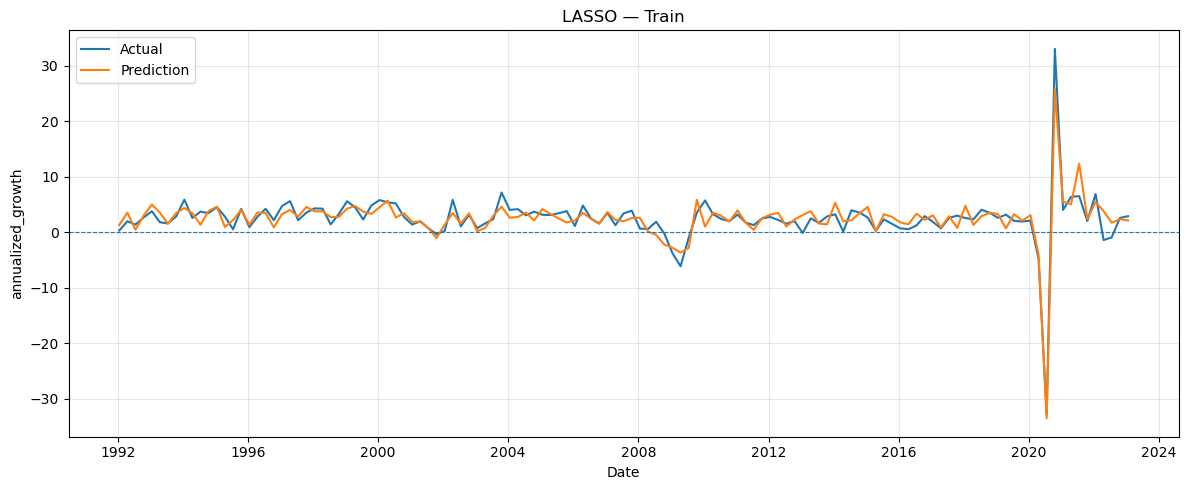

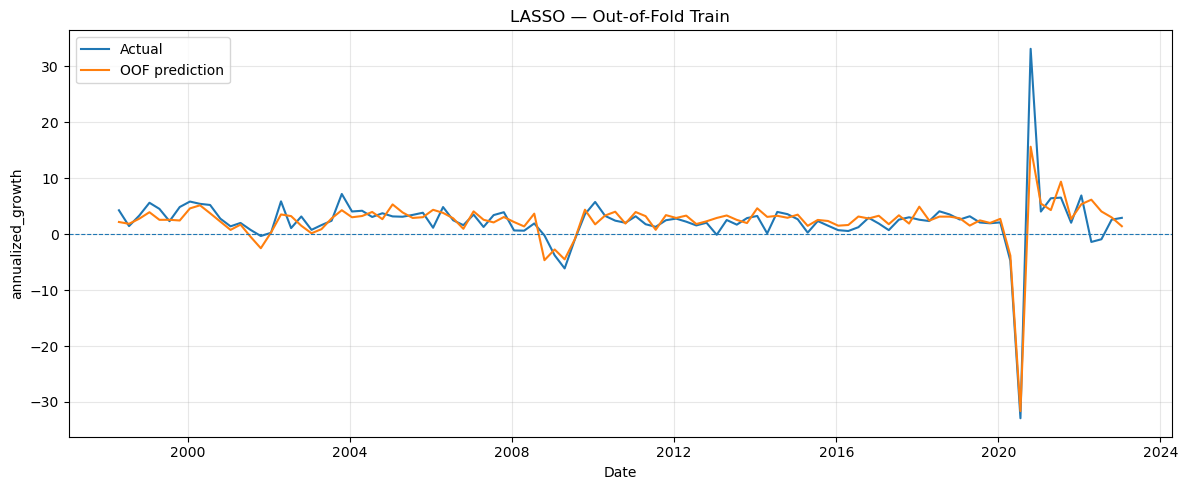

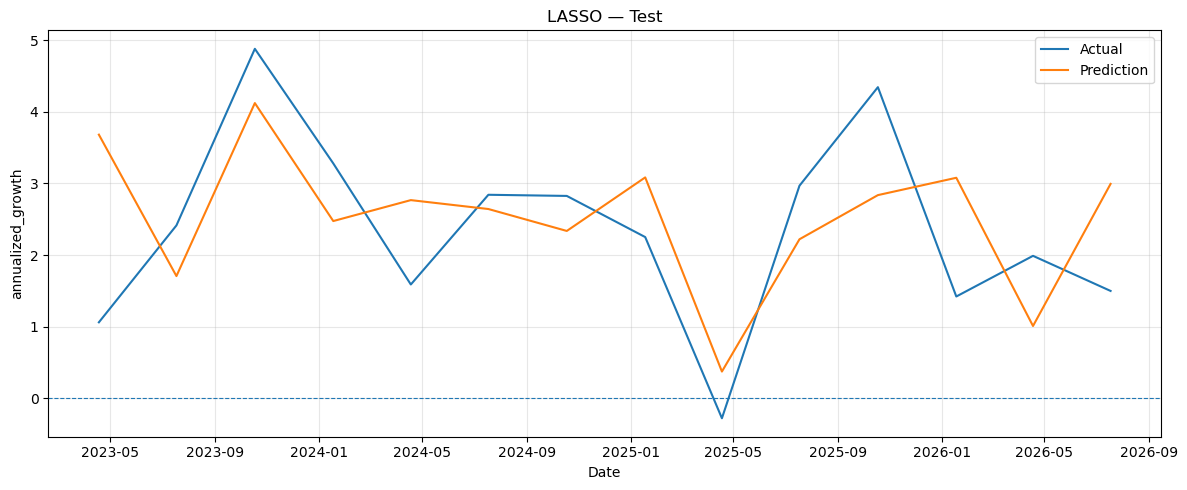

In [325]:
RUN_MODEL = True
MODEL_TYPE = "lasso"

if RUN_MODEL:

    import TrainingModels
    import AnalyseModels

    trainer = TrainingModels.TrainingModels(
        X_train=X_train,
        y_train=y_train,
        model_type=MODEL_TYPE,
        n_splits=5,
        dates_train=dates_train,
        random_state=42,
        pca_bool = False
    )

    best_model = trainer.tune(
        n_trials=50
    )

    print(
        "CV score:",
        trainer.get_cv_score()
    )

    oof_predictions = (
        trainer.create_oof_predictions()
    )

    display(oof_predictions.head())

    analysis = AnalyseModels.AnalyseModels(
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        model_type=MODEL_TYPE,
        label_type=TARGET_TYPE,
        dates_train=dates_train,
        dates_test=dates_test
    )

    display(
        analysis.metrics()
    )
            
    if(MODEL_TYPE in ["linear","ridge","lasso","elasticnet"]):
        display(
            analysis.feature_coefficients()
        )
    analysis.plot_predictions()
else:
    print(
        "Model training is disabled. "
        "Review the diagnostics above first."
    )


In [326]:
import ModelsComparaisons

model_types = [
    "dumb_model",
    "linear",
    "ridge",
    "lasso",
    "elasticnet",
    "xgb",
    "catboost"
]

models_comparison = (
    ModelsComparaisons.ModelsComparaisons(
        model_types=model_types,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        dates_train=dates_train,
        label_type="annualized_log_growth"
    )
)

comparison = (
    models_comparison
    .run_all(
        n_trials=50,
        n_splits=5,
        pca_bool=False
    )
)

display(comparison)

models_comparison.compare_pca(
    n_trials=50,
    n_splits=5
)

pca_table = (
    models_comparison.build_pca_comparison_df()
)

display(
    pca_table
)


TRAINING MODEL: LINEAR
Best model saved to: /Users/raphaelbreaud/Desktop/Project/QuantCubeProject/data/models/linear/best_model.pkl

Model: linear
CV RMSE: 2.2799 +/- 1.4078
Best parameters: {}
OOF predictions saved to: /Users/raphaelbreaud/Desktop/Project/QuantCubeProject/data/models/linear/oof_predictions.csv

TRAINING MODEL: RIDGE


  0%|          | 0/50 [00:00<?, ?it/s]

Best model saved to: /Users/raphaelbreaud/Desktop/Project/QuantCubeProject/data/models/ridge/best_model.pkl

Model: ridge
CV RMSE: 2.0904 +/- 1.2689
Best parameters: {'alpha': 8.496522981272534}
OOF predictions saved to: /Users/raphaelbreaud/Desktop/Project/QuantCubeProject/data/models/ridge/oof_predictions.csv

TRAINING MODEL: LASSO


  0%|          | 0/50 [00:00<?, ?it/s]

Best model saved to: /Users/raphaelbreaud/Desktop/Project/QuantCubeProject/data/models/lasso/best_model.pkl

Model: lasso
CV RMSE: 2.0746 +/- 1.2482
Best parameters: {'alpha': 0.02996876792465927}
OOF predictions saved to: /Users/raphaelbreaud/Desktop/Project/QuantCubeProject/data/models/lasso/oof_predictions.csv

TRAINING MODEL: ELASTICNET


  0%|          | 0/50 [00:00<?, ?it/s]

Best model saved to: /Users/raphaelbreaud/Desktop/Project/QuantCubeProject/data/models/elasticnet/best_model.pkl

Model: elasticnet
CV RMSE: 2.0832 +/- 1.3124
Best parameters: {'alpha': 0.04663807766063781, 'l1_ratio': 0.8525230444735926}
OOF predictions saved to: /Users/raphaelbreaud/Desktop/Project/QuantCubeProject/data/models/elasticnet/oof_predictions.csv

TRAINING MODEL: XGB


  0%|          | 0/50 [00:00<?, ?it/s]

[W 2026-09-19 23:06:47,576] Trial 21 failed with parameters: {'n_estimators': 396, 'max_depth': 2, 'learning_rate': 0.1301123113881616, 'subsample': 0.7744097671427833, 'colsample_bytree': 0.7384317941827554, 'min_child_weight': 6, 'reg_alpha': 1.0379095322720887e-06, 'reg_lambda': 0.004174540415539677} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/Users/raphaelbreaud/Desktop/Project/QuantCubeProject/src/TrainingModels.py", line 550, in _objective
    pipeline.fit(
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py", line 649, in fit
    self._final_estimato

KeyboardInterrupt: 

### Benchmark note

For the target used in this notebook — the **initial-release GDP level** — the natural persistence benchmark is:

\[
\widehat{GDP_t} = GDP_{t-1}
\]

So the dumb model should predict the previous observed GDP level, not zero.

For a level-target model, it can also be useful to include `last_quarter_gdp` as an explicit predictor/anchor, provided it is constructed only from information available before the current-quarter target release.

For evaluation, MAE and RMSE are especially useful. R² can also be reported, but because GDP level is strongly trending, always compare against the persistence benchmark.
